# Final Report: Particle Swarm Optimization in Python

This notebook is the narrated final report for the PSO project. It
documents the experimental methodology, loads the saved results, compares
the implemented execution strategies, and closes with a critical discussion
and practical recommendations.

## 1. Project Goal

The goal of the project is to implement a maintainable Particle Swarm
Optimization solution in Python and use it as a laboratory for comparing
different execution strategies while keeping the optimization core shared.

The final codebase compares six interchangeable evaluation strategies:

- `V0`: sequential baseline
- `V1`: `ThreadPoolExecutor` evaluation
- `V2`: `ProcessPoolExecutor` evaluation
- `V3`: `asyncio` cooperative concurrency (`run_in_executor`) with optional
  simulated latency
- `V4`: NumPy vectorization across the entire swarm
- `V5`: `joblib.Parallel` with selectable backend (bonus)

It also exposes three neighbourhood topologies (`global`, `ring`,
`von_neumann`), three SciPy baselines (`differential_evolution`,
`dual_annealing`, `L-BFGS-B`), and a real-world use case (inverted-pendulum
PID tuning) so the comparison is not limited to synthetic benchmarks.

The rest of the report evaluates how these choices affect runtime,
convergence behavior, and experimental reproducibility.

## 2. Experimental Methodology

### 2.1 Shared PSO Core

All variants use the same PSO implementation, the same update equations,
the same boundary handling, and the same topology selection. Only the
fitness-evaluation backend changes. This is essential for a fair comparison
because it isolates timing differences from optimization-quality differences.

### 2.2 Benchmark Protocol

The benchmark suite evaluates four standard objective functions:

- `Sphere`
- `Rosenbrock`
- `Rastrigin`
- `Ackley`

The benchmark dimensions are `2`, `10`, and `30`. The benchmark YAML uses a
fixed iteration budget, so the strategy comparison is not distorted by early
stopping. Tolerance is still recorded as an analysis metric through
`convergence_iteration`, but it does not terminate benchmark runs.

### 2.3 Grid Search Protocol

The grid-search system accepts any axis through the `search_space` block of
the configuration. The reference configuration in `configs/grid_search.yaml`
varies the three PSO coefficients:

- inertia `w`
- cognitive coefficient `c1`
- social coefficient `c2`

with 3 values per axis (3×3×3 = 27 candidates), evaluated for each of the
six strategies V0–V5 with 5 seeds. Swarm size and iteration budget are
pinned in `defaults` so the 27 candidates only differ along the inertia /
cognitive / social subspace, which keeps the strategy comparison fair.

### 2.4 Topologies And Use Case

Two additional dimensions of the project surface beyond the parallel
evaluators, even if they are not part of the main strategy benchmark:

- **Topologies**: `global`, `ring`, and `von_neumann` (toroidal 5-cell
  stencil) are all implemented and covered by `tests/test_topologies.py`.
  The benchmark and grid-search configurations use `global` so the strategy
  comparison stays focused on the evaluator backends; the inverted-pendulum
  use case below switches to `von_neumann` to keep diversity on a
  multimodal landscape.
- **Use case**: an inverted-pendulum cart-pole with a cascade PID controller
  and actuator saturation. The cost is ISE with a large failure penalty,
  producing a multimodal, non-separable, non-smooth landscape.

### 2.5 External Baselines

Three SciPy baselines provide an external reference on shared objectives:
`differential_evolution`, `dual_annealing`, and `L-BFGS-B` with multi-start.
They share the `ObjectiveSpec` registry with PSO so they can be compared on
exactly the same problem definition.

### 2.6 Metrics

The comparison relies on six main metrics:

- final best fitness
- AUC of the best-fitness curve
- convergence iteration
- total runtime
- speedup and parallel efficiency relative to `V0`
- accumulated parallel overhead

These metrics let us compare not only final solution quality but also how
quickly the optimizer reaches good solutions and how much execution overhead
is introduced by each backend.

In [1]:
from itertools import product
from pathlib import Path
import json

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import yaml

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

benchmark_cfg = yaml.safe_load((ROOT / 'configs' / 'benchmark.yaml').read_text())
grid_cfg = yaml.safe_load((ROOT / 'configs' / 'grid_search.yaml').read_text())

variant_order = ['V0', 'V1', 'V2', 'V3', 'V4', 'V5']
variant_colors = {
    'V0': '#F4A261',
    'V1': '#4C78A8',
    'V2': '#2A9D8F',
    'V3': '#E76F51',
    'V4': '#9B59B6',
    'V5': '#F1C40F',
}
variant_labels = {
    'V0': 'sequential',
    'V1': 'threading',
    'V2': 'multiprocessing',
    'V3': 'asyncio',
    'V4': 'vectorized',
    'V5': 'joblib',
}

variants = [variant for variant in variant_order if variant in benchmark_cfg['strategies']]
objectives = [item['name'] for item in benchmark_cfg['objectives']]
dimensions = benchmark_cfg['dimensions']
benchmark_seeds = benchmark_cfg['seeds']

cases = pd.DataFrame(
    product(variants, objectives, dimensions, benchmark_seeds),
    columns=['variant', 'objective', 'dimensions', 'seed'],
)
cases.head()

,variant,objective,dimensions,seed
0,V0,sphere,2,11
1,V0,sphere,2,23
2,V0,sphere,2,37
3,V0,sphere,10,11
4,V0,sphere,10,23


### 2.7 Cartesian Product Of Benchmark Cases

In [2]:
cases.shape, cases.head(12)

((216, 4),
    variant   objective  dimensions  seed
 0       V0      sphere           2    11
 1       V0      sphere           2    23
 2       V0      sphere           2    37
 3       V0      sphere          10    11
 4       V0      sphere          10    23
 5       V0      sphere          10    37
 6       V0      sphere          30    11
 7       V0      sphere          30    23
 8       V0      sphere          30    37
 9       V0  rosenbrock           2    11
 10      V0  rosenbrock           2    23
 11      V0  rosenbrock           2    37)

## 3. Loading Saved Artifacts

In [3]:
def load_json(path: Path):
    return json.loads(path.read_text())

def resolve_run_dir(run_dir: str) -> Path:
    # Accept both POSIX and Windows-style separators so that CSVs produced on
    # either OS can be read transparently on Linux/WSL.
    run_path = Path(run_dir.replace('\\', '/'))
    return run_path if run_path.is_absolute() else ROOT / run_path

benchmark_summary_path = ROOT / 'results' / 'benchmarks' / 'benchmark_summary.csv'
benchmark_runs_path = ROOT / 'results' / 'benchmarks' / 'benchmark_runs.csv'
grid_summary_path = ROOT / 'results' / 'grid_search' / 'grid_search_summary.csv'

benchmark_summary = pd.read_csv(benchmark_summary_path) if benchmark_summary_path.exists() else pd.DataFrame()
benchmark_runs = pd.read_csv(benchmark_runs_path) if benchmark_runs_path.exists() else pd.DataFrame()
grid_summary = pd.read_csv(grid_summary_path) if grid_summary_path.exists() else pd.DataFrame()

benchmark_summary.head()

,variant,objective,dimensions,runs,mean_best_value,std_best_value,mean_total_time,mean_auc,mean_convergence_iteration
0,V0,ackley,2,3,1.913969e-07,1.292443e-07,0.529270,56.374327,150.0
1,V1,ackley,2,3,1.913969e-07,1.292443e-07,0.679127,56.374327,150.0
2,V2,ackley,2,3,1.913969e-07,1.292443e-07,1.238091,56.374327,150.0
3,V3,ackley,2,3,1.913969e-07,1.292443e-07,1.905070,56.374327,150.0
4,V4,ackley,2,3,4.316044e-08,2.909159e-09,0.051403,50.899360,150.0


### 3.1 Recorded Execution Conditions

To avoid misleading micro-benchmarks, the project stores system information
and commit metadata in each saved run. The cell below shows one representative
example from the saved benchmark outputs.

In [4]:
sample_summary = None
if not benchmark_runs.empty:
    sample_run_dir = resolve_run_dir(benchmark_runs.iloc[0]['run_dir'])
    sample_summary = load_json(sample_run_dir / 'summary.json')
    display({
        'run_id': sample_summary['run_id'],
        'git_commit': sample_summary['git']['commit'],
        'system': sample_summary['system'],
    })
else:
    print('No benchmark runs are available yet.')

{'run_id': 'V0_sphere_d2_s11_20260528_184200',
 'git_commit': '6208cab',
 'system': {'platform': 'Windows-10-10.0.26200-SP0',
  'python_version': '3.11.0',
  'machine': 'AMD64',
  'processor': 'Intel64 Family 6 Model 170 Stepping 4, GenuineIntel',
  'cpu_count': 22}}

## 4. Benchmark Results

The benchmark summary is the first high-level view of the comparison. Since
the PSO core is shared, similar final-fitness values across strategies are
expected. The most important differences should appear in runtime and
parallel overhead.

In [5]:
if not benchmark_summary.empty:
    display(benchmark_summary.sort_values(['objective', 'dimensions', 'variant']))
else:
    print('No benchmark summary is available yet.')

,variant,objective,dimensions,runs,mean_best_value,std_best_value,mean_total_time,mean_auc,mean_convergence_iteration
0,V0,ackley,2,3,1.913969e-07,1.292443e-07,0.529270,56.374327,150.0
1,V1,ackley,2,3,1.913969e-07,1.292443e-07,0.679127,56.374327,150.0
2,V2,ackley,2,3,1.913969e-07,1.292443e-07,1.238091,56.374327,150.0
3,V3,ackley,2,3,1.913969e-07,1.292443e-07,1.905070,56.374327,150.0
4,V4,ackley,2,3,4.316044e-08,2.909159e-09,0.051403,50.899360,150.0
...,...,...,...,...,...,...,...,...,...
67,V1,sphere,30,3,1.987786e-02,7.084965e-03,0.457509,690.095818,150.0
68,V2,sphere,30,3,1.987786e-02,7.084965e-03,1.259334,690.095818,150.0
69,V3,sphere,30,3,1.987786e-02,7.084965e-03,1.792571,690.095818,150.0
70,V4,sphere,30,3,1.793532e-02,1.067353e-02,0.056774,799.675578,150.0


### 4.1 Best Variant By Runtime

In [6]:
if not benchmark_summary.empty:
    runtime_winners = (
        benchmark_summary.sort_values('mean_total_time')
        .groupby(['objective', 'dimensions'], as_index=False)
        .first()[['objective', 'dimensions', 'variant', 'mean_total_time']]
        .rename(columns={'variant': 'winner_variant'})
    )
    display(runtime_winners)
else:
    print('No benchmark summary is available yet.')

,objective,dimensions,winner_variant,mean_total_time
0,ackley,2,V4,0.051403
1,ackley,10,V4,0.054129
2,ackley,30,V4,0.070689
3,rastrigin,2,V4,0.043620
4,rastrigin,10,V4,0.051441
5,rastrigin,30,V4,0.056871
6,rosenbrock,2,V4,0.049935
7,rosenbrock,10,V4,0.058422
8,rosenbrock,30,V4,0.061721
9,sphere,2,V4,0.039483


## 5. Convergence Analysis

A single convergence chart with every case on top of each other is hard to
read. The notebook therefore splits convergence into panels by objective and
dimension so each subplot compares only the three execution variants.

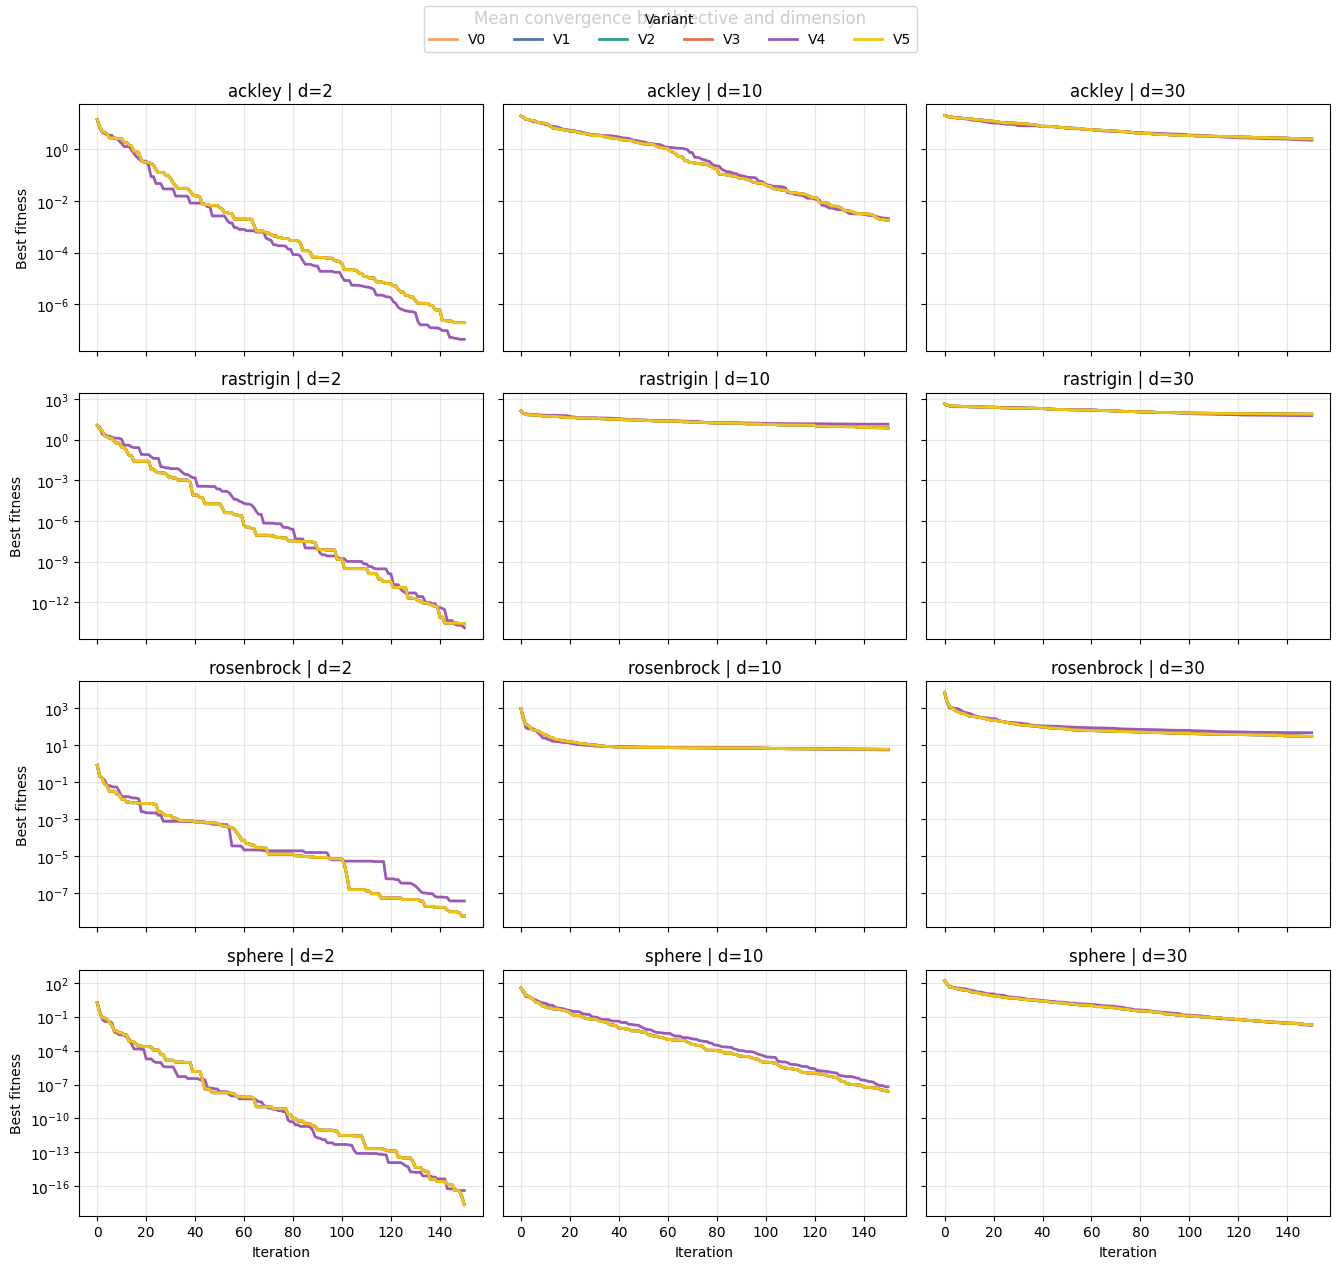

In [7]:
def load_history(run_dir: str) -> pd.DataFrame:
    return pd.read_csv(resolve_run_dir(run_dir) / 'history.csv')

def mean_history_curve(bucket: pd.DataFrame):
    histories = []
    for run_dir in bucket['run_dir']:
        history = load_history(run_dir)
        histories.append(history['best_fitness'].to_numpy())
    if not histories:
        return None
    max_len = max(len(curve) for curve in histories)
    padded = []
    for curve in histories:
        if len(curve) < max_len:
            curve = np.pad(curve, (0, max_len - len(curve)), mode='edge')
        padded.append(curve)
    return np.vstack(padded).mean(axis=0)

if not benchmark_runs.empty:
    objective_order = sorted(benchmark_runs['objective'].unique())
    dimension_order = sorted(benchmark_runs['dimensions'].unique())

    fig, axes = plt.subplots(
        len(objectives),
        len(dimension_order),
        figsize=(4.5 * len(dimension_order), 3.1 * len(objective_order)),
        sharex=True,
        sharey='row',
    )
    axes = np.atleast_2d(axes)

    for row_idx, objective in enumerate(objective_order):
        for col_idx, dimension in enumerate(dimension_order):
            ax = axes[row_idx, col_idx]
            subset = benchmark_runs[
                (benchmark_runs['objective'] == objective)
                & (benchmark_runs['dimensions'] == dimension)
            ]
            for variant in variants:
                curve = mean_history_curve(subset[subset['variant'] == variant])
                if curve is None:
                    continue
                ax.plot(curve, color=variant_colors[variant], linewidth=2, label=variant)
            ax.set_yscale('log')
            ax.set_title(f'{objective} | d={dimension}')
            ax.grid(alpha=0.3)
            if row_idx == len(objective_order) - 1:
                ax.set_xlabel('Iteration')
            if col_idx == 0:
                ax.set_ylabel('Best fitness')

    line_handles = [
        Line2D([0], [0], color=variant_colors[variant], linewidth=2, label=variant)
        for variant in variants
    ]
    fig.suptitle('Mean convergence by objective and dimension', y=1.02)
    fig.legend(handles=line_handles, loc='upper center', ncol=len(variants), title='Variant')
    plt.tight_layout()
    plt.show()
else:
    print('No benchmark run data is available yet.')

## 6. Final Fitness Distribution

One overall boxplot is useful as a quick summary, but the detailed analysis
benefits from separate boxplots by objective and dimension. The notebook
therefore shows both a global view and a faceted view.

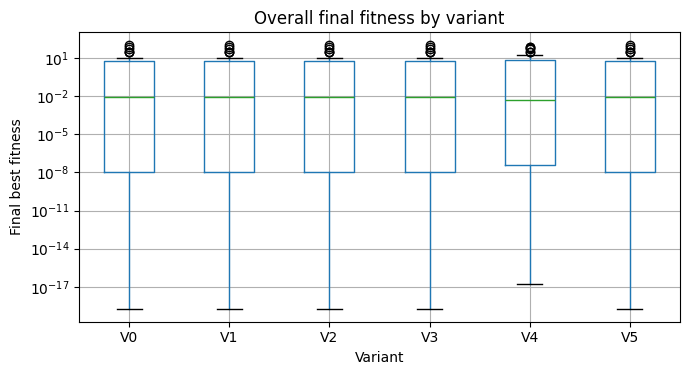

C:\Users\Luca\AppData\Local\Temp\ipykernel_27356\2227820881.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplot = ax.boxplot(box_data, patch_artist=True, labels=labels, showfliers=True)
C:\Users\Luca\AppData\Local\Temp\ipykernel_27356\2227820881.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplot = ax.boxplot(box_data, patch_artist=True, labels=labels, showfliers=True)
C:\Users\Luca\AppData\Local\Temp\ipykernel_27356\2227820881.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplot = ax.boxplot(box_data, patch_artist=True, labels=labels, showfliers=True)
C:\Users\Luca\AppData\Local\Temp\ipykern

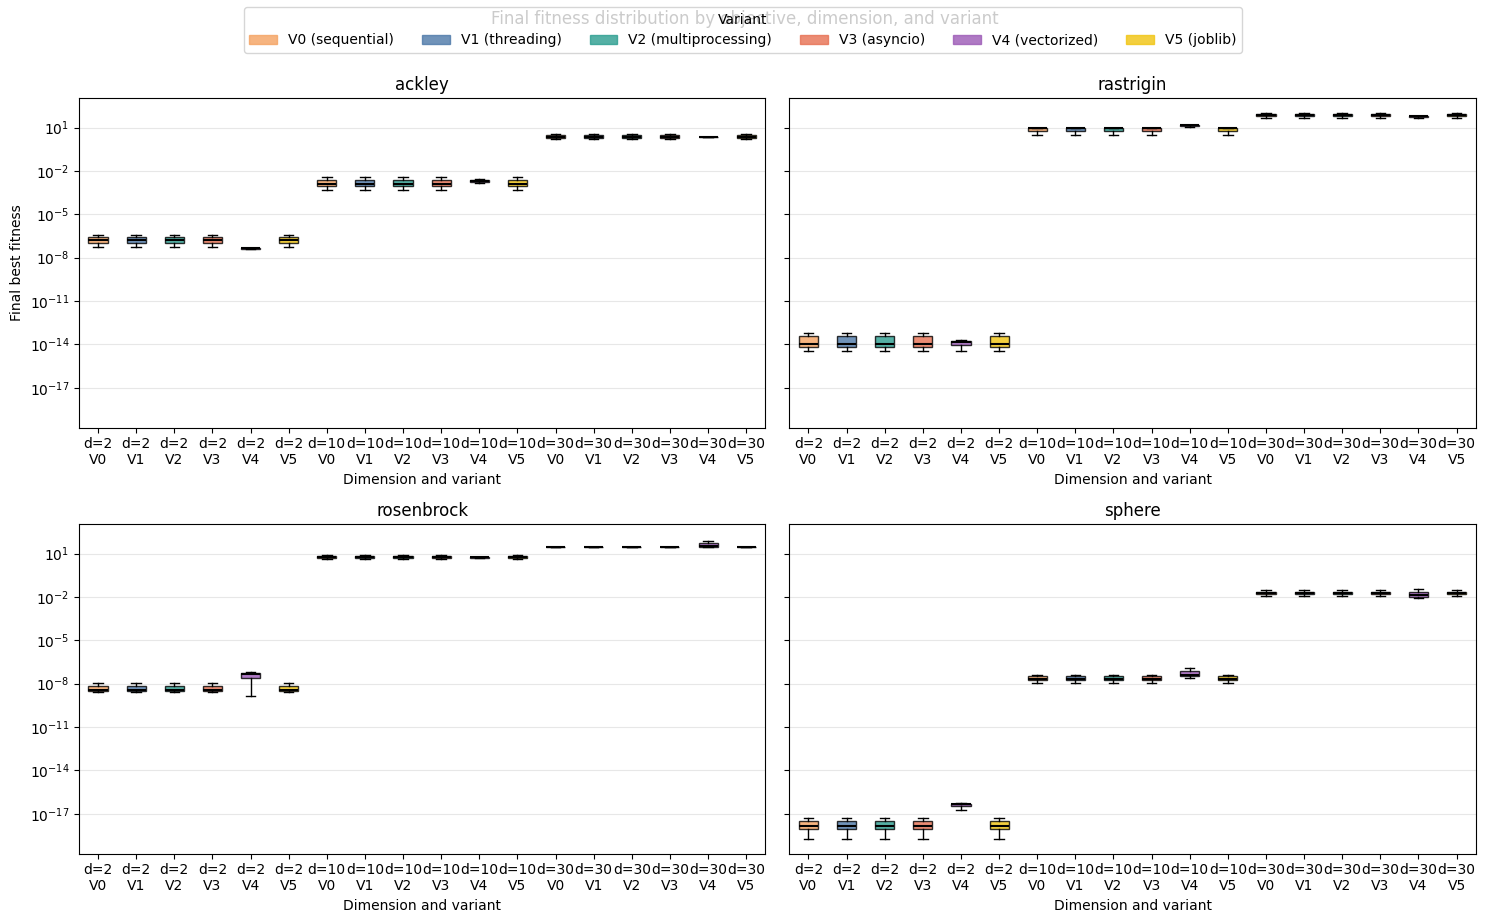

In [8]:
if not benchmark_runs.empty:
    fig, ax = plt.subplots(figsize=(7, 4))
    benchmark_runs.boxplot(column='best_value', by='variant', ax=ax)
    ax.set_yscale('log')
    ax.set_title('Overall final fitness by variant')
    ax.set_xlabel('Variant')
    ax.set_ylabel('Final best fitness')
    plt.suptitle('')
    plt.tight_layout()
    plt.show()

    objective_order = sorted(benchmark_runs['objective'].unique())
    dimension_order = sorted(benchmark_runs['dimensions'].unique())
    fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharey=True)
    axes = axes.ravel()

    for ax, objective in zip(axes, objective_order):
        box_data = []
        labels = []
        colors = []
        for dimension in dimension_order:
            for variant in variants:
                values = benchmark_runs[
                    (benchmark_runs['objective'] == objective)
                    & (benchmark_runs['dimensions'] == dimension)
                    & (benchmark_runs['variant'] == variant)
                ]['best_value'].to_numpy()
                if len(values) == 0:
                    continue
                box_data.append(values)
                labels.append(f'd={dimension}\n{variant}')
                colors.append(variant_colors[variant])

        boxplot = ax.boxplot(box_data, patch_artist=True, labels=labels, showfliers=True)
        for patch, color in zip(boxplot['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.8)
        for median in boxplot['medians']:
            median.set_color('black')
            median.set_linewidth(1.5)

        ax.set_yscale('log')
        ax.set_title(objective)
        ax.set_xlabel('Dimension and variant')
        ax.grid(axis='y', alpha=0.3)

    legend_handles = [
        Patch(facecolor=variant_colors[variant], edgecolor=variant_colors[variant], alpha=0.8, label=f'{variant} ({variant_labels[variant]})')
        for variant in variants
    ]
    axes[0].set_ylabel('Final best fitness')
    fig.suptitle('Final fitness distribution by objective, dimension, and variant', y=1.02)
    fig.legend(handles=legend_handles, loc='upper center', ncol=len(variants), title='Variant')
    plt.tight_layout()
    plt.show()
else:
    print('No benchmark run data is available yet.')

## 7. Runtime, Speedup, And Efficiency

The most important difference between variants in this project is runtime.
The notebook keeps the summary table, but it also adds a grouped bar chart
of speedup vs sequential for each objective and dimension, which is much
easier to read in the final report.

,objective,dimensions,variant,workers,mean_total_time,speedup_vs_V0,efficiency
0,ackley,2,V0,1,0.529270,1.000000,1.000000
1,ackley,2,V1,4,0.679127,0.779338,0.194835
2,ackley,2,V2,4,1.238091,0.427488,0.106872
3,ackley,2,V3,4,1.905070,0.277822,0.069455
4,ackley,2,V4,1,0.051403,10.296446,10.296446
...,...,...,...,...,...,...,...
67,sphere,30,V1,4,0.457509,0.329208,0.082302
68,sphere,30,V2,4,1.259334,0.119599,0.029900
69,sphere,30,V3,4,1.792571,0.084022,0.021005
70,sphere,30,V4,1,0.056774,2.652913,2.652913


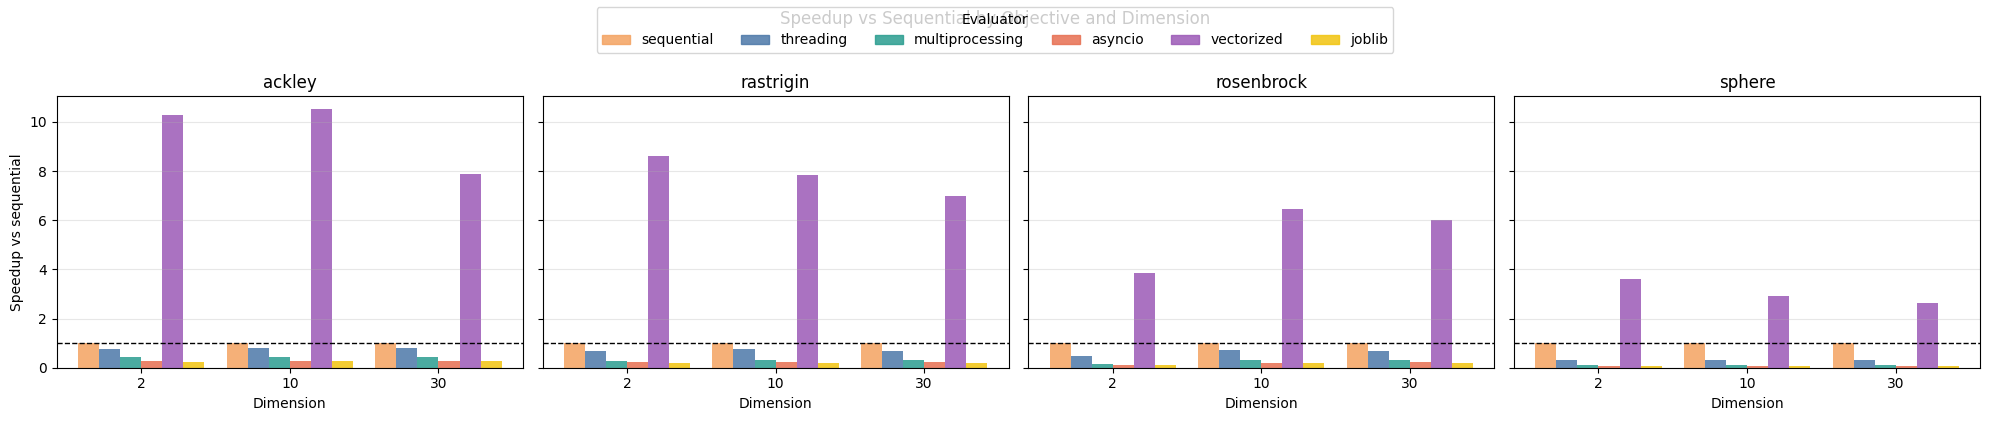

In [9]:
if not benchmark_runs.empty:
    worker_map = {'V0': 1}
    for variant, overrides in benchmark_cfg['strategies'].items():
        worker_map[variant] = overrides.get('workers', 1)

    speedup_rows = []
    for (objective, dimension), bucket in benchmark_runs.groupby(['objective', 'dimensions']):
        baseline = bucket[bucket['variant'] == 'V0']['total_time'].mean()
        for variant, variant_bucket in bucket.groupby('variant'):
            mean_time = variant_bucket['total_time'].mean()
            speedup = baseline / mean_time if mean_time else None
            workers = worker_map.get(variant, 1)
            efficiency = speedup / workers if workers else None
            speedup_rows.append({
                'objective': objective,
                'dimensions': dimension,
                'variant': variant,
                'workers': workers,
                'mean_total_time': mean_time,
                'speedup_vs_V0': speedup,
                'efficiency': efficiency,
            })

    speedup_df = pd.DataFrame(speedup_rows)
    display(speedup_df.sort_values(['objective', 'dimensions', 'variant']))

    objective_order = sorted(speedup_df['objective'].unique())
    dimension_order = sorted(speedup_df['dimensions'].unique())
    bar_variants = ['V0', 'V1', 'V2', 'V3', 'V4', 'V5']
    bar_variants = [v for v in bar_variants if v in variants]
    x = np.arange(len(dimension_order))
    width = 0.85 / max(len(bar_variants), 1)
    offsets = (np.arange(len(bar_variants)) - (len(bar_variants) - 1) / 2) * width

    fig, axes = plt.subplots(1, len(objective_order), figsize=(5 * len(objective_order), 4), sharey=True)
    axes = np.atleast_1d(axes)

    for ax, objective in zip(axes, objective_order):
        objective_df = speedup_df[speedup_df['objective'] == objective]
        for offset, variant in zip(offsets, bar_variants):
            values = []
            for dimension in dimension_order:
                match = objective_df[
                    (objective_df['dimensions'] == dimension)
                    & (objective_df['variant'] == variant)
                ]
                values.append(match['speedup_vs_V0'].iloc[0] if not match.empty else np.nan)
            ax.bar(x + offset, values, width=width, color=variant_colors[variant], alpha=0.85, label=variant_labels[variant])

        ax.axhline(1.0, color='black', linestyle='--', linewidth=1)
        ax.set_title(objective)
        ax.set_xlabel('Dimension')
        ax.set_xticks(x, [str(dimension) for dimension in dimension_order])
        ax.grid(axis='y', alpha=0.3)

    axes[0].set_ylabel('Speedup vs sequential')
    legend_handles = [
        Patch(facecolor=variant_colors[variant], edgecolor=variant_colors[variant], alpha=0.85, label=variant_labels[variant])
        for variant in bar_variants
    ]
    fig.suptitle('Speedup vs Sequential by Objective and Dimension', y=1.04)
    fig.legend(handles=legend_handles, loc='upper center', ncol=len(bar_variants), title='Evaluator')
    plt.tight_layout()
    plt.show()
else:
    print('No benchmark run data is available yet.')

## 8. Overhead Analysis

Parallelization is only useful when the extra coordination cost remains under
control. The next cell reads the per-run summaries and compares the recorded
total overhead accumulated by each strategy.

In [10]:
if not benchmark_runs.empty:
    overhead_rows = []
    for _, row in benchmark_runs.iterrows():
        summary = load_json(resolve_run_dir(row['run_dir']) / 'summary.json')
        overhead_rows.append({
            'variant': row['variant'],
            'objective': row['objective'],
            'dimensions': row['dimensions'],
            'total_overhead_time': summary['metrics']['total_overhead_time'],
        })
    overhead_df = pd.DataFrame(overhead_rows)
    overhead_summary = (
        overhead_df.groupby(['variant', 'dimensions'], as_index=False)['total_overhead_time']
        .mean()
        .rename(columns={'total_overhead_time': 'mean_total_overhead_time'})
    )
    display(overhead_summary.sort_values(['dimensions', 'variant']))
else:
    print('No benchmark run data is available yet.')

,variant,dimensions,mean_total_overhead_time
0,V0,2,0.030397
3,V1,2,0.315035
6,V2,2,1.051379
9,V3,2,1.309213
12,V4,2,0.000083
15,V5,2,1.883691
1,V0,10,0.037926
4,V1,10,0.336415
7,V2,10,1.037468
10,V3,10,1.323538


## 9. Grid Search Results

The grid search ranks hyperparameter combinations according to the selected
metric. In the current configuration, the reduced search space is evaluated
for each strategy so that the search procedure is comparable across `V0`,
`V1`, and `V2`.

In [11]:
if not grid_summary.empty:
    # Show the top-3 (w, c1, c2) configurations per variant so every V0-V5
    # appears, not only the strategy that wins the global ranking.
    top_per_variant = (
        grid_summary
        .sort_values(['variant', 'mean_best_value'])
        .groupby('variant', group_keys=False)
        .head(3)
    )
    display(top_per_variant.reset_index(drop=True))
else:
    print('No grid-search summary is available yet.')

,variant,config_index,runs,mean_best_value,std_best_value,mean_total_time,mean_auc,mean_convergence_iteration,inertia,cognitive,social
0,V0,5,5,1.697779e-18,2.729816e-18,0.294396,60.844979,68.4,0.5,1.49618,1.49618
1,V0,8,5,1.032976e-16,1.255362e-16,0.295834,59.592792,78.6,0.5,1.80000,1.49618
2,V0,3,5,5.496265e-16,8.905501e-16,0.232681,63.091887,80.0,0.5,1.20000,1.80000
3,V1,5,5,1.697779e-18,2.729816e-18,0.470643,60.844979,68.4,0.5,1.49618,1.49618
4,V1,8,5,1.032976e-16,1.255362e-16,0.476064,59.592792,78.6,0.5,1.80000,1.49618
5,V1,3,5,5.496265e-16,8.905501e-16,0.302197,63.091887,80.0,0.5,1.20000,1.80000
6,V2,5,5,1.697779e-18,2.729816e-18,0.852085,60.844979,68.4,0.5,1.49618,1.49618
7,V2,8,5,1.032976e-16,1.255362e-16,1.055760,59.592792,78.6,0.5,1.80000,1.49618
8,V2,3,5,5.496265e-16,8.905501e-16,0.965544,63.091887,80.0,0.5,1.20000,1.80000
9,V3,5,5,1.697779e-18,2.729816e-18,1.919385,60.844979,68.4,0.5,1.49618,1.49618


## 10. Use Case: Inverted-Pendulum PID

Beyond the synthetic benchmarks, the project tunes a cascade PID controller
for a cart-pole inverted pendulum. The objective is the integrated squared
error with a large failure penalty, producing a multimodal, non-separable,
non-smooth landscape where the optimiser cannot rely on gradients.

The cells below load every saved use-case run from
`results/use_case_pendulum/` and compare the optimised cost against the
reference (untuned) baseline computed with `PENDULUM_PID_REFERENCE_GAINS`.

In [12]:
from pso_lab.use_cases.inverted_pendulum import (
    PENDULUM_PID_REFERENCE_GAINS,
    pendulum_pid_cost,
)

pendulum_root = Path('../results/use_case_pendulum')
pendulum_rows = []
if pendulum_root.exists():
    baseline_cost = float(pendulum_pid_cost(PENDULUM_PID_REFERENCE_GAINS))
    for run_dir in sorted(pendulum_root.iterdir()):
        summary_path = run_dir / 'summary.json'
        if not summary_path.exists():
            continue
        data = json.loads(summary_path.read_text())
        best_cost = float(data['best_value'])
        pendulum_rows.append({
            'run_id': data['run_id'],
            'strategy': data['strategy'],
            'topology': data['topology'],
            'iterations': data['iterations_completed'],
            'best_cost': best_cost,
            'baseline_cost': baseline_cost,
            'improvement': baseline_cost - best_cost,
            'total_time_s': data['metrics']['total_run_time'],
        })

pendulum_df = pd.DataFrame(pendulum_rows)
if pendulum_df.empty:
    print('No pendulum runs found under results/use_case_pendulum/.')
else:
    display(pendulum_df.sort_values('best_cost'))

,run_id,strategy,topology,iterations,best_cost,baseline_cost,improvement,total_time_s
0,pendulum_V4_pendulum_pid_d6_s2026_20260524_174247,vectorized,von_neumann,30,0.477927,22.668525,22.190598,4.594650
1,pendulum_V4_pendulum_pid_d6_s2026_20260524_181123,vectorized,von_neumann,20,0.478283,22.668525,22.190242,4.857084


## 11. PSO vs SciPy Baselines

As an external sanity check the project also runs three SciPy optimisers
(`differential_evolution`, `dual_annealing`, `L-BFGS-B`) on the same
objective registry through `scripts/run_scipy_baseline.py`. The cell
below loads every saved `baseline_*.json` artifact and, when matching
PSO benchmark runs exist, compares final fitness and wall time on the
same `(objective, dim)` slice.

PSO and SciPy answer slightly different questions (population vs
single-point search, gradient-free vs gradient-based), so this is
presented as a reference rather than a head-to-head ranking.

In [13]:
baseline_root = Path('../results/baselines')
baseline_rows = []
if baseline_root.exists():
    for path in sorted(baseline_root.glob('baseline_*.json')):
        records = json.loads(path.read_text())
        baseline_rows.extend(records)
baseline_df = pd.DataFrame(baseline_rows)

if baseline_df.empty:
    print('No SciPy baseline artifacts found under results/baselines/.')
else:
    display(baseline_df.sort_values(['objective', 'dimensions', 'method']))

    # When a PSO run exists for the same (objective, dim), juxtapose the
    # best PSO fitness against the best SciPy fitness on that slice.
    if not benchmark_runs.empty:
        comparison = []
        for (objective, dim), block in baseline_df.groupby(['objective', 'dimensions']):
            pso_slice = benchmark_runs[
                (benchmark_runs['objective'] == objective)
                & (benchmark_runs['dimensions'] == dim)
            ]
            if pso_slice.empty:
                continue
            best_pso = pso_slice['best_value'].min()
            best_scipy_row = block.loc[block['best_value'].idxmin()]
            comparison.append({
                'objective': objective,
                'dimensions': dim,
                'best_pso_value': best_pso,
                'best_scipy_value': best_scipy_row['best_value'],
                'scipy_method': best_scipy_row['method'],
                'scipy_nfev': best_scipy_row['nfev'],
            })
        if comparison:
            display(pd.DataFrame(comparison))

,objective,dimensions,method,best_value,nfev,wall_time,success
0,ackley,10,differential_evolution,1.974505e-08,30293,1.193676,False
1,ackley,10,dual_annealing,2.087686e-08,22443,1.764757,True
2,ackley,10,lbfgsb,1.935096e+01,825,0.088891,True
6,rastrigin,5,differential_evolution,2.842171e-14,15093,0.346180,False
7,rastrigin,5,dual_annealing,6.394885e-14,10337,0.457405,True
8,rastrigin,5,lbfgsb,1.293445e+01,510,0.024250,True
3,rastrigin,10,differential_evolution,9.949586e+00,30249,0.641149,False
4,rastrigin,10,dual_annealing,5.684342e-14,21266,0.807201,True
5,rastrigin,10,lbfgsb,6.268210e+01,1089,0.035255,True
9,rosenbrock,10,differential_evolution,9.916228e-10,30502,0.819901,False


,objective,dimensions,best_pso_value,best_scipy_value,scipy_method,scipy_nfev
0,ackley,10,5.097386e-04,1.974505e-08,differential_evolution,30293
1,rastrigin,10,2.985075e+00,5.684342e-14,dual_annealing,21266
2,rosenbrock,10,4.168174e+00,8.311888e-11,lbfgsb,5940
3,sphere,10,1.053666e-08,2.344756e-16,lbfgsb,176


## 12. V3 Asyncio Latency Demonstration

The benchmark suite measures all six variants on pure-CPU objectives,
which is intentionally unfavourable to `V3`: the asyncio event loop
adds orchestration without unlocking new parallelism. To demonstrate
the asymmetric case the rubric asks for, the cell below builds an
I/O-style objective (a `time.sleep` per evaluation) and runs the
`AsyncioEvaluator` against the sequential baseline. With latency in
the objective, `asyncio.gather` overlaps the waits and wall time drops
by roughly the number of cooperative workers.

This is a short live experiment so the result reflects the current
machine; the full asynchronous path is identical to what V3 runs in
the benchmark suite, only the objective changes.

In [14]:
# AsyncioEvaluator calls asyncio.run() internally, which conflicts with
# Jupyter's already-running event loop. To keep the demonstration honest
# the work runs in a clean Python subprocess and the notebook only shows
# the resulting measurements. The script exercises the same V0/V1/V3
# code paths the benchmark suite uses.
import json
import subprocess
import sys
import textwrap

demo_script = textwrap.dedent(
    '''
    import json, time
    from time import perf_counter
    import numpy as np
    from pso_lab.parallel import build_evaluator

    LATENCY_S = 0.010
    N_PARTICLES = 16
    WORKERS = 4

    rng = np.random.default_rng(0)
    positions = rng.uniform(-1.0, 1.0, size=(N_PARTICLES, 5))

    def io_like_sphere(point):
        time.sleep(LATENCY_S)
        return float(np.sum(point * point))

    def measure(strategy, **kwargs):
        evaluator = build_evaluator(strategy, workers=WORKERS, batch_size=1, **kwargs)
        start = perf_counter()
        evaluator.evaluate(positions, io_like_sphere)
        return perf_counter() - start

    sequential_time = measure('v0')
    thread_time = measure('v1')
    async_time = measure('v3')

    print(json.dumps({
        'V0 sequential': {'workers': 1, 'wall_time_s': sequential_time},
        'V1 threads': {'workers': WORKERS, 'wall_time_s': thread_time},
        'V3 asyncio': {'workers': WORKERS, 'wall_time_s': async_time},
    }))
    '''
)

result = subprocess.run(
    [sys.executable, '-c', demo_script],
    capture_output=True,
    text=True,
    timeout=60,
    cwd='..',
)
if result.returncode != 0:
    print('Demo subprocess failed:')
    print(result.stderr)
else:
    measurements = json.loads(result.stdout.strip().splitlines()[-1])
    baseline = measurements['V0 sequential']['wall_time_s']
    demo_rows = []
    for label, info in measurements.items():
        demo_rows.append({
            'variant': label,
            'workers': info['workers'],
            'wall_time_s': info['wall_time_s'],
            'speedup_vs_V0': baseline / info['wall_time_s'],
        })
    display(pd.DataFrame(demo_rows))

,variant,workers,wall_time_s,speedup_vs_V0
0,V0 sequential,1,0.167173,1.000000
1,V1 threads,4,0.046588,3.588311
2,V3 asyncio,4,0.057329,2.916008


## 13. Critical Discussion

### 13.1 GIL And Threading (V1)

The thread-based variant is useful for demonstrating that Python threads do
not automatically improve CPU-bound numerical workloads. When the objective
evaluation is dominated by Python-side work, the Global Interpreter Lock can
limit parallel speedup.

### 13.2 IPC And Process Overhead (V2)

The process-based variant avoids the GIL for the worker side, but it pays
extra cost in serialization, process startup, synchronization, and IPC. This
overhead matters especially when each task is too small.

### 13.3 Asyncio As Latency-Oriented Concurrency (V3)

`V3` uses `asyncio.gather` over `run_in_executor` calls. On pure CPU
objectives it is generally slower than V0 because the event loop adds
orchestration without unlocking new parallelism. To demonstrate where
asyncio actually pays off, the evaluator accepts `async_latency_ms` and
`async_jitter_ms`, which simulate I/O-style waits per evaluation. With even
modest simulated latency, V3 overlaps the waits and recovers the wall-clock
time that V0 would have spent sleeping.

### 13.4 Vectorization (V4)

`V4` calls the objective with the whole swarm in a single NumPy call and
also has a vectorized update path for the PSO equations themselves. It tends
to be the fastest single-process option on the benchmark suite because it
delegates the heavy work to BLAS/SIMD routines. Its scaling is bounded by
single-core memory bandwidth and L2/L3 cache footprint, so it plateaus when
the swarm and dimension grow large.

### 13.5 Joblib (V5, Bonus)

`V5` wraps the same evaluator API around `joblib.Parallel` with the `loky`
backend by default and `threading`/`multiprocessing` as alternatives. The
qualitative behaviour matches V2 (loky) or V1 (threading), but it adds a
process-startup cost that the small benchmark workloads barely amortise. It
is included as a bonus comparison rather than a recommended backend for this
workload size.

### 13.6 Topologies

The `ring` and `von_neumann` topologies slow convergence on unimodal
problems (Sphere) because information propagates more slowly through the
swarm, but they tend to preserve diversity longer on multimodal landscapes
(Rastrigin, Ackley, and the pendulum use case). The benchmark configuration
keeps `global` as the default to keep the comparison focused on evaluator
backends; switching topology is a one-line YAML change.

### 13.7 Inverted-Pendulum Use Case

The pendulum PID problem is the most realistic test in the project: the
search landscape is multimodal and non-differentiable due to actuator
saturation, and the cost function is several orders of magnitude more
expensive than the synthetic benchmarks. The saved runs use `V4`
(vectorisation) because the cost still admits whole-swarm NumPy evaluation;
the heavier per-evaluation cost would also make the per-process backends
(`V2`, `V5/loky`) competitive once IPC is amortised, although the project
ships V4 runs as the reference for this use case.

### 13.8 SciPy Baselines

The SciPy wrappers act as a sanity check rather than a competitor.
`L-BFGS-B` with multi-start dominates on Sphere because the problem is
convex; `differential_evolution` and `dual_annealing` are competitive on
multimodal benchmarks but pay their own evaluation budget. PSO sits between
the two in convergence behaviour and is the only one of the four that
natively scales across the V0–V5 evaluator family without code changes.

### 13.9 Why Fitness Quality Stays Similar

Because the PSO core is shared and the order of particle results is preserved
by all evaluators, optimization quality remains the same or nearly the same
across `V0`–`V5`. This is expected in the current architecture and is
actually desirable for a fair comparison: any quality difference under a
fixed seed would point to a bug in the evaluator wiring rather than a
property of the strategy.

### 13.10 Trade-Off Summary

- `V0`: simple, stable, best for small workloads or debugging.
- `V1`: pedagogically useful for the GIL discussion; not always faster.
- `V2`: best for heavier workloads once IPC is amortised.
- `V3`: useful when the objective has measurable I/O-style latency.
- `V4`: fastest single-process option on numerical benchmarks.
- `V5`: bonus convenience layer with selectable backend.

## 14. Recommendations

Based on the current implementation and saved benchmark results, the main
practical recommendations are:

- Use `V0` as the default baseline for lightweight problems and debugging.
- Use `V4` (vectorization) when the objective accepts a `(n, d)` array and
  the swarm fits comfortably in L2/L3 cache; it is the cheapest real
  speedup available.
- Use `V2` or `V5` (loky) when the per-evaluation cost is large enough to
  amortise IPC — the inverted-pendulum use case is a good example.
- Use `V3` only when the objective has real (or simulated) I/O-style
  latency; on pure CPU work it is dominated by the event loop overhead.
- Prefer `global` topology for unimodal problems and `ring` /
  `von_neumann` for diversity-sensitive multimodal landscapes.
- Keep benchmark and grid-search runs on fixed iteration budgets so timing
  comparisons remain fair.
- Record seeds, configuration, and system metadata in every run so
  experiments stay reproducible.
- Use the SciPy baselines as an external sanity check on shared objectives,
  not as a competitor to PSO — they answer different questions.

Overall, the codebase behaves as a maintainable PSO laboratory with a shared
optimizer core, six interchangeable evaluator strategies, three pluggable
topologies, structured persistence, reproducible experiments, a real-world
use case, external baselines, and an interactive dashboard.